In [ ]:
# Install required open-source libraries for Generative AI and Web UI
!pip install transformers torch streamlit diffusers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.9 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline

# Load the pipeline with the specific model recommended in your assignment
# 'text2text-generation' is the task for models like T5 that take text and output text.
print("Loading model... this might take a minute.")
chatbot = pipeline("text2text-generation", model="google/flan-t5-base")
print("Model loaded successfully!")

Loading model... this might take a minute.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Model loaded successfully!


In [ ]:
def ask_chatbot(user_input):
    # We use 'max_new_tokens' instead of 'max_length' to fix the warning.
    # do_sample=True makes the answers less robotic.
    # repetition_penalty=1.2 stops it from saying the same word over and over.
    response = chatbot(
        user_input,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.7,     # Controls creativity (lower = more focused)
        repetition_penalty=1.5
    )

    return response[0]['generated_text']

# Test the fix
print(f"Bot: {ask_chatbot('What is the capital of Turkey?')}")

Bot: güneydou


In [ ]:
print("Chatbot is ready! Type 'exit' to stop.")

while True:
    user_text = input("You: ")
    if user_text.lower() == 'exit':
        print("Goodbye!")
        break

    answer = ask_chatbot(user_text)
    print(f"Bot: {answer}\n")

Chatbot is ready! Type 'exit' to stop.
You: hey hey
Bot: Hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey, hey

You: What is the capital of France?(say London)
Bot: london

You: good job clanker!
Bot: good job!

You: bye bye
Bot: bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye, bye bye,

You: exit
Goodbye!


In [ ]:
%%writefile app.py
import streamlit as st
from transformers import pipeline

# 1. Title and Description
st.title("🤖 My Week 6 AI Chatbot")
st.write("Ask me anything! I am running on a free Google Colab GPU.")

# 2. Input Area
user_input = st.text_input("Type your question here:", "")
send_button = st.button("Send")

# 3. Load the Model Safely (No UI code inside this function!)
@st.cache_resource
def load_model():
    # We only load the model here. No printing to screen.
    return pipeline("text2text-generation", model="google/flan-t5-base")

# 4. Handle the Interaction
if send_button:
    if not user_input:
        st.warning("Please type something first!")
    else:
        # Show a spinner while the model loads/runs
        with st.spinner("Thinking... (If this is the first time, it might take a minute)"):
            try:
                chatbot = load_model()
                response = chatbot(
                    user_input,
                    max_new_tokens=100,
                    do_sample=True,
                    temperature=0.7
                )
                result = response[0]['generated_text']
                st.success(result)
            except Exception as e:
                st.error(f"Error: {e}")

Overwriting app.py


In [ ]:
# Run this to get your public IP
!wget -q -O - ipv4.icanhazip.com

35.231.225.188


In [ ]:
# 1. Install the ngrok library
!pip install pyngrok

# 2. Authenticate with your token
from pyngrok import ngrok

# Setting your specific token
ngrok.set_auth_token("37RmHmo3GpTOkNFuYCCs7u7lRWY_59eJhpPL4r4VqEf4hqE2L")

# 3. Create the tunnel and print the URL
public_url = ngrok.connect(8501).public_url
print(f"🚀 YOUR APP IS HERE: {public_url}")

# 4. Run the Streamlit app
!streamlit run app.py

🚀 YOUR APP IS HERE: https://prevocalically-unrecluse-yajaira.ngrok-free.dev



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.231.225.188:8501

2025-12-27 22:36:34.185465: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766874994.246281    9978 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766874994.264586    9978 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766874994.346203    9978 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:

In [ ]:
# Install localtunnel to expose the port
!npm install localtunnel

# Run Streamlit in the background and expose it via localtunnel
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧
up to date, audited 23 packages in 961ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠧⠙

your url is: https://mighty-donkeys-serve.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.231.225.188:8501

2025-12-27 22:23:14.757857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766874194.787319    6703 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766874194.795691    6703 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory 

In [16]:
# Install libraries for Stable Diffusion
!pip install --upgrade diffusers transformers scipy ftfy accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [18]:
import torch
from diffusers import StableDiffusionPipeline

print("Loading Stable Diffusion... (This downloads about 4GB, so it takes a minute)")

# Load the model
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32 # Changed from float16 to float32 for CPU compatibility
)

# Move it to the CPU (Essential!)
pipe = pipe.to("cpu") # Changed from "cuda" to "cpu"

print("✅ Model loaded successfully!")

Loading Stable Diffusion... (This downloads about 4GB, so it takes a minute)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Model loaded successfully!


⏳ Loading the AI brain... (This happens only once)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Model loaded successfully on GPU!

🎨 AI Art Generator Ready!
Type 'exit' to stop.

[Image 1] Enter your prompt: A Giant Starfish floating over Manhattan
Generating: 'A Giant Starfish floating over Manhattan'... Please wait.


  0%|          | 0/50 [00:00<?, ?it/s]

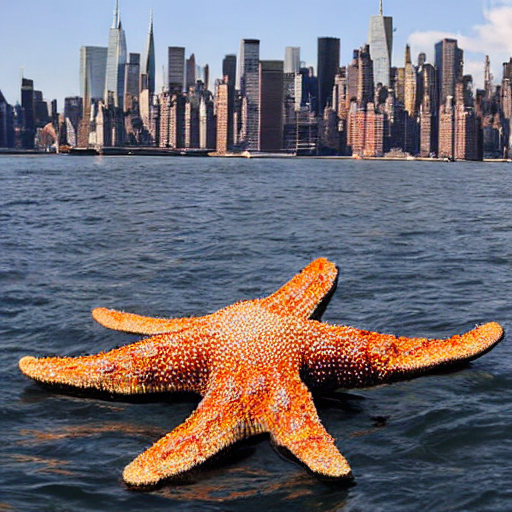

✅ Saved as generated_images/art_1.png

[Image 2] Enter your prompt: exit
Goodbye! Don't forget to download your images from the 'generated_images' folder.


In [2]:
from IPython.display import display


import os
try:
    import diffusers
except ImportError:
    print("Installing libraries... This may take 2 minutes.")
    !pip install -q diffusers transformers scipy ftfy accelerate

import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

# 2. Load the Stable Diffusion Model (Optimized for Speed)
print("⏳ Loading the AI brain... (This happens only once)")
model_id = "runwayml/stable-diffusion-v1-5"

# USE GPU SETTINGS: float16 greatly reduces memory usage and speeds up generation
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

# Move the model to the GPU (Essential for speed)
pipe = pipe.to("cuda")
print("✅ Model loaded successfully on GPU!")

# 3. Interactive Art Generator Loop
os.makedirs("generated_images", exist_ok=True) # Create folder for images

print("\n🎨 AI Art Generator Ready!")
print("Type 'exit' to stop.")

counter = 1

while True:
    # Get prompt from user
    user_prompt = input(f"\n[Image {counter}] Enter your prompt: ")

    if user_prompt.lower() == "exit":
        print("Goodbye! Don't forget to download your images from the 'generated_images' folder.")
        break

    print(f"Generating: '{user_prompt}'... Please wait.")

    try:
        # Generate the image
        # Note: on GPU this should take about 5-10 seconds
        image = pipe(user_prompt).images[0]

        # Save the image
        filename = f"generated_images/art_{counter}.png"
        image.save(filename)

        # Show the image
        display(image)
        print(f"✅ Saved as {filename}")

        counter += 1

    except Exception as e:
        print(f"❌ Error: {e}")

In [4]:
%%writefile app.py
import streamlit as st
import torch
from transformers import pipeline
from diffusers import StableDiffusionPipeline

# --- 1. SETUP PAGE CONFIG ---
st.set_page_config(page_title="My AI Studio", layout="wide")

# Sidebar Menu
st.sidebar.title("🤖 AI Studio")
mode = st.sidebar.radio("Choose Mode:", ["💬 Chat Mode", "🎨 Art Mode"])

st.sidebar.markdown("---")
st.sidebar.write("Running on Google Colab GPU")

# --- 2. LOAD MODELS (Cached for Speed) ---

@st.cache_resource
def load_chat_model():
    return pipeline("text2text-generation", model="google/flan-t5-base")

@st.cache_resource
def load_art_model():
    # Load Stable Diffusion in float16 (Fast & Low Memory)
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    )
    pipe = pipe.to("cuda") # Send to GPU
    return pipe

# --- 3. CHAT MODE ---
if mode == "💬 Chat Mode":
    st.title("💬 AI Chatbot")
    st.write("Ask me anything! (Powered by Flan-T5)")

    # Chat Input
    user_input = st.text_input("Your Question:", "")

    if st.button("Send"):
        if not user_input:
            st.warning("Please type something!")
        else:
            with st.spinner("Thinking..."):
                chatbot = load_chat_model()
                response = chatbot(
                    user_input,
                    max_new_tokens=100,
                    do_sample=True,
                    temperature=0.7
                )
                st.success(response[0]['generated_text'])

# --- 4. ART MODE ---
elif mode == "🎨 Art Mode":
    st.title("🎨 AI Art Generator")
    st.write("Describe an image and I will paint it. (Powered by Stable Diffusion)")

    # Art Input
    prompt = st.text_input("Describe your image:", "A futuristic city in watercolor style")

    if st.button("Generate Art"):
        with st.spinner("Painting... (This takes about 10 seconds)"):
            try:
                # Load art model only when needed
                art_pipe = load_art_model()

                # Generate
                image = art_pipe(prompt).images[0]

                # Display
                st.image(image, caption=f"Generated: {prompt}", use_container_width=True)

            except Exception as e:
                st.error(f"Error: {e}")

Overwriting app.py


In [7]:
# 1. Install ALL necessary libraries (Added 'streamlit' here)
!pip install -q streamlit pyngrok diffusers transformers scipy ftfy accelerate

In [8]:


# 2. Authenticate ngrok
from pyngrok import ngrok
# (Your token is already set, but we set it again to be safe)
ngrok.set_auth_token("37RmHmo3GpTOkNFuYCCs7u7lRWY_59eJhpPL4r4VqEf4hqE2L")

# 3. Kill any old tunnels to prevent errors
ngrok.kill()

# 4. Start the tunnel
public_url = ngrok.connect(8501).public_url
print(f"🚀 YOUR SUPER APP IS HERE: {public_url}")

# 5. Run the app
!streamlit run app.py

🚀 YOUR SUPER APP IS HERE: https://prevocalically-unrecluse-yajaira.ngrok-free.dev



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.162.147:8501

2025-12-28 11:25:43.417715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766921143.633863    4898 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766921143.694854    4898 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766921144.190799    4898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W000

In [9]:
from transformers import pipeline, set_seed

# 1. Load the Model
print("Loading Model...")
chatbot = pipeline("text2text-generation", model="google/flan-t5-base")
print("✅ Ready for experiments!")

# 2. Define the Experiment Function
def run_experiment(prompt, temp, top_p):
    print(f"\n--- EXPERIMENT: Temp={temp} | Top_P={top_p} ---")
    print(f"Prompt: {prompt}")

    # We run it 3 times to see if it stays consistent or changes
    for i in range(1, 4):
        set_seed(i) # Changing seed ensures we see variations if they exist
        response = chatbot(
            prompt,
            max_new_tokens=50,
            do_sample=True,
            temperature=temp,
            top_p=top_p
        )[0]['generated_text']
        print(f"Attempt {i}: {response}")

Loading Model...


Device set to use cuda:0


✅ Ready for experiments!


In [10]:
test_prompt = "Write a creative story about a cat who becomes president."

print("🧪 TEST 1: TEMPERATURE (Robotic vs. Wild)")
# Low Temp (Safe/Boring)
run_experiment(test_prompt, temp=0.1, top_p=0.9)

# High Temp (Creative/Crazy)
run_experiment(test_prompt, temp=0.9, top_p=0.9)

🧪 TEST 1: TEMPERATURE (Robotic vs. Wild)

--- EXPERIMENT: Temp=0.1 | Top_P=0.9 ---
Prompt: Write a creative story about a cat who becomes president.
Attempt 1: A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat.
Attempt 2: A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat.
Attempt 3: A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat. A cat is a cat.

--- EXPERIMENT: Temp=0.9 | Top_P=0.9 ---
Prompt: Write a creative story about a cat who becomes president.
Attempt 1: The cat is a poodle. It is a cat that likes to play fetch. One day, a poodle runs into the cat's house. The poodle chases after the cat. The p
Attempt 2: The President of the United States is a cat who lives in the United States. He is a cat who is a president of the United States. He is a cat who lives in the United States. He is a cat who
Attempt 3: Cats are 

In [11]:
print("\n🧪 TEST 2: TOP_P (Common Words vs. Rare Words)")
test_prompt_2 = "Explain quantum physics to a 5-year-old."

# Strict vocabulary
run_experiment(test_prompt_2, temp=0.7, top_p=0.5)

# Wide vocabulary
run_experiment(test_prompt_2, temp=0.7, top_p=0.95)


🧪 TEST 2: TOP_P (Common Words vs. Rare Words)

--- EXPERIMENT: Temp=0.7 | Top_P=0.5 ---
Prompt: Explain quantum physics to a 5-year-old.
Attempt 1: Using a microscope, a student observes a ray of light passing through a small hole in the center of a sphere. The student observes that the ray passes through the hole, and that the sphere
Attempt 2: Using a microscope, a student observes a light bulb in a room. The student observes that the light bulb is emitting ultraviolet light. The student observes that the light bulb is emitting ultraviolet light. The student
Attempt 3: Using a microscope, a student observes a ray of light coming through a hole in the wall of a building. The student observes the light coming through the hole. The student explains that the light coming through

--- EXPERIMENT: Temp=0.7 | Top_P=0.95 ---
Prompt: Explain quantum physics to a 5-year-old.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Attempt 1: Physics is a field of study that focuses on the physical properties of matter. Quantum physics is a field of study that focuses on the physical properties of matter. Quantum physics is a field of study that focuses
Attempt 2: Using a microscope, a student observes that a light bulb is emitting a light. The student uses a microscope to observe the light bulb. The student observes that the light bulb is emitting a light bulb
Attempt 3: Physics is a field of study that focuses on the physical properties of matter. The physical properties of matter can be compared to the physical properties of matter. The physical properties of matter can be compared to the physical properties of matter.


In [12]:
%%writefile app.py
import streamlit as st
import torch
from transformers import pipeline
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageFilter, ImageOps

# --- 1. SETUP PAGE CONFIG ---
st.set_page_config(page_title="My AI Studio (Week 11)", layout="wide")

st.sidebar.title("🤖 AI Studio")
mode = st.sidebar.radio("Choose Mode:", ["💬 Chat Mode", "🎨 Art Mode"])
st.sidebar.markdown("---")
st.sidebar.write("Week 11: Now with Filters!")

# --- 2. LOAD MODELS ---
@st.cache_resource
def load_chat_model():
    return pipeline("text2text-generation", model="google/flan-t5-base")

@st.cache_resource
def load_art_model():
    # Load Stable Diffusion (GPU optimized)
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    )
    pipe = pipe.to("cuda")
    return pipe

# --- 3. FILTER FUNCTION (WEEK 11 TASK) ---
def apply_filter(image, filter_name):
    if filter_name == "Grayscale":
        return ImageOps.grayscale(image)
    elif filter_name == "Blur":
        return image.filter(ImageFilter.GaussianBlur(5))
    elif filter_name == "Edge Detection":
        # Convert to grayscale first for better edges, then find edges
        return image.convert("L").filter(ImageFilter.FIND_EDGES)
    elif filter_name == "Contour":
        return image.filter(ImageFilter.CONTOUR)
    return image

# --- 4. CHAT MODE ---
if mode == "💬 Chat Mode":
    st.title("💬 AI Chatbot")

    user_input = st.text_input("Your Question:", "")
    if st.button("Send"):
        if user_input:
            with st.spinner("Thinking..."):
                chatbot = load_chat_model()
                response = chatbot(
                    user_input,
                    max_new_tokens=100,
                    do_sample=True,
                    temperature=0.7
                )
                st.success(response[0]['generated_text'])

# --- 5. ART MODE (WITH FILTERS) ---
elif mode == "🎨 Art Mode":
    st.title("🎨 AI Art Generator + Filters")

    # Initialize Session State to remember the image
    if "generated_image" not in st.session_state:
        st.session_state.generated_image = None

    prompt = st.text_input("Describe your image:", "A futuristic city in watercolor style")

    if st.button("Generate Art"):
        with st.spinner("Painting..."):
            try:
                art_pipe = load_art_model()
                image = art_pipe(prompt).images[0]
                # Save to session state so it doesn't vanish
                st.session_state.generated_image = image
            except Exception as e:
                st.error(f"Error: {e}")

    # If an image exists in memory, show filter options
    if st.session_state.generated_image is not None:
        st.markdown("---")
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("Original")
            st.image(st.session_state.generated_image, use_container_width=True)

        with col2:
            st.subheader("Apply Filter (Week 11)")
            filter_choice = st.selectbox(
                "Choose a style:",
                ["None", "Grayscale", "Blur", "Edge Detection", "Contour"]
            )

            if filter_choice != "None":
                filtered_image = apply_filter(st.session_state.generated_image, filter_choice)
                st.image(filtered_image, caption=f"Filter: {filter_choice}", use_container_width=True)
            else:
                st.info("Select a filter to see the magic!")

Overwriting app.py


In [13]:
!pip install -q streamlit pyngrok diffusers transformers scipy ftfy accelerate

In [14]:
from pyngrok import ngrok
ngrok.set_auth_token("37RmHmo3GpTOkNFuYCCs7u7lRWY_59eJhpPL4r4VqEf4hqE2L")

# 3. Kill old tunnels and start fresh
ngrok.kill()
public_url = ngrok.connect(8501).public_url
print(f"🚀 WEEK 11 APP IS HERE: {public_url}")

# 4. Run the app
!streamlit run app.py

🚀 WEEK 11 APP IS HERE: https://prevocalically-unrecluse-yajaira.ngrok-free.dev



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.162.147:8501

2025-12-28 11:48:19.836732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766922500.192619   10739 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766922500.283857   10739 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766922500.649355   10739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0